# Linear Regression
    y = mX+c
    where,
        y = predict data
        m = slope/coefficient (each feature has different slope)
        X = data point
        c = intercept / constatnt

# Real state house price prediction using Regression models

In [35]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Linear regression model
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet

# Random Forest Model
from sklearn.ensemble import RandomForestRegressor

# Train Test Split
from sklearn.model_selection import train_test_split, KFold, cross_val_score #KFold and cross val score for cross validation

# Feature Scaling
from sklearn.preprocessing import StandardScaler, PolynomialFeatures # Polynomial Features for Polynomial regression model

# Import pipeline
from sklearn.pipeline import Pipeline

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [36]:
df = pd.read_csv('D:\Data Science\Dataset\Real estate.csv')
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\Acer\AppData\Local\Temp\ipykernel_21456\1393760261.py:1: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv('D:\Data Science\Dataset\Real estate.csv')


,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


### Data Cleaning

In [37]:
# Remove unwanted columns
df = df.drop(columns=['No','X1 transaction date'])

In [38]:
df.isnull().sum()

X2 house age                              0
X3 distance to the nearest MRT station    0
X4 number of convenience stores           0
X5 latitude                               0
X6 longitude                              0
Y house price of unit area                0
dtype: int64

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 414 entries, 0 to 413
Data columns (total 6 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   X2 house age                            414 non-null    float64
 1   X3 distance to the nearest MRT station  414 non-null    float64
 2   X4 number of convenience stores         414 non-null    int64  
 3   X5 latitude                             414 non-null    float64
 4   X6 longitude                            414 non-null    float64
 5   Y house price of unit area              414 non-null    float64
dtypes: float64(5), int64(1)
memory usage: 19.5 KB


#### Box plot for detecting outliers

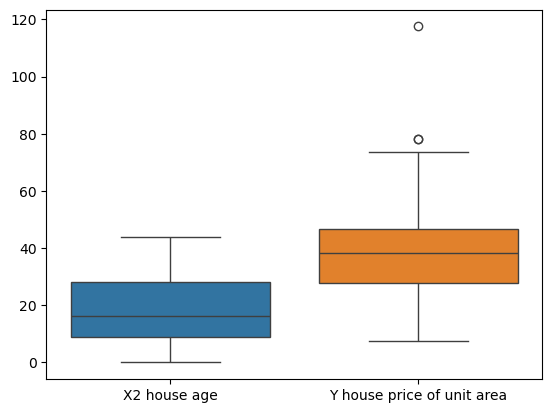

In [40]:
sns.boxplot(df[['X2 house age','Y house price of unit area']])
plt.show()

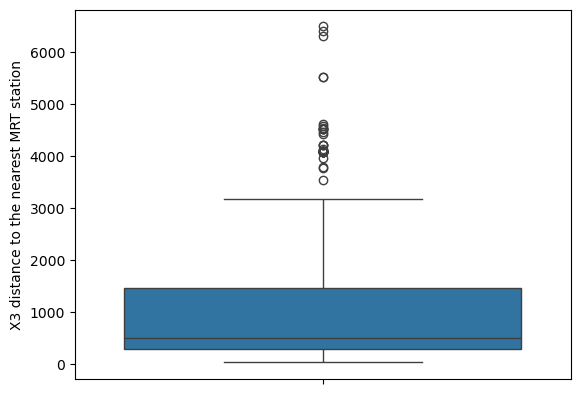

In [41]:
sns.boxplot(df['X3 distance to the nearest MRT station'])
plt.show()

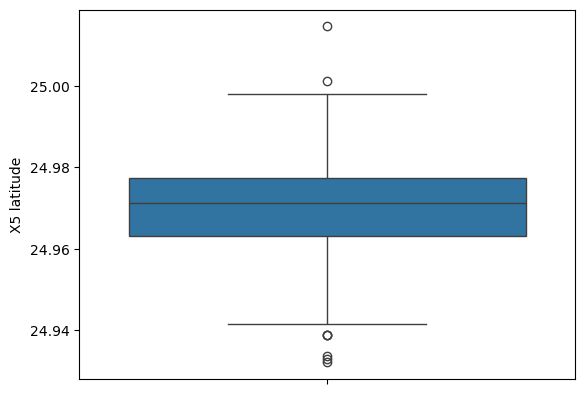

In [42]:
sns.boxplot(df['X5 latitude'])
plt.show()

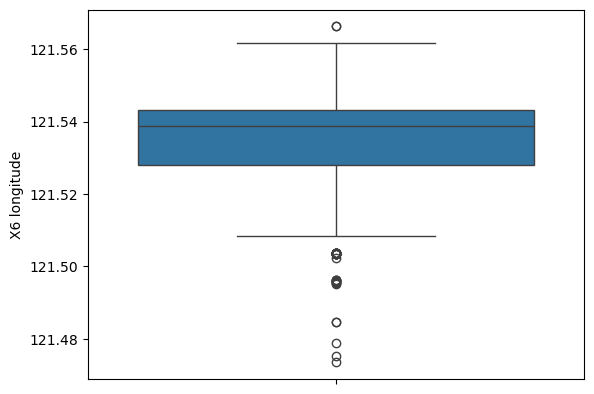

In [43]:
sns.boxplot(df['X6 longitude'])
plt.show()

In [44]:
# address data ma outlier vayepani kaile remove nagarne

# Feature and Target

In [45]:
df.columns

Index(['X2 house age', 'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       'Y house price of unit area'],
      dtype='object')

In [46]:
feature = ['X2 house age', 'X3 distance to the nearest MRT station',
       'X4 number of convenience stores', 'X5 latitude', 'X6 longitude',
       ]
X= df[feature]
target = 'Y house price of unit area'
Y = df[target]

## Train Test Split

In [47]:
X_train, X_test, Y_train, Y_test = train_test_split(
    X,Y, test_size =0.2, random_state=42
)
# random state le data like shuffle garera 42th index dekhi 20% data lai test set banaune aru train
# test_size =0.2 means 20% test aru train so 80-20

## Feature Scaling

In [48]:
'''
(Xi-Mean)/SD
Feature Traning -> fit_transform()
    -Fit-> Learning -> Calculates mean and SD
Feature Testing -> transform()
    -Transform-> Implement -> Implements formula into data(formula from training fit ie mean and sd)
'''

'\n(Xi-Mean)/SD\nFeature Traning -> fit_transform()\n    -Fit-> Learning -> Calculates mean and SD\nFeature Testing -> transform()\n    -Transform-> Implement -> Implements formula into data(formula from training fit ie mean and sd)\n'

In [49]:
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train)
X_test_scale = scaler.fit_transform(X_test)

## Model Implementation

In [50]:
model = LinearRegression() #n_jobs=1 le cpu ko 1 core lai matra allocate garxa
# Train model
model.fit(X_train_scale, Y_train)

LinearRegression()

In [51]:
Y_pred = model.predict(X_test_scale)
Y_pred

array([48.75576065, 43.18633894, 45.56849849, 42.34148729, 32.54546723,
       44.26138495, 47.25423469, 47.1743536 , 26.28813485, 53.12029712,
       34.16378368, 36.93984233, 41.67127694, 26.41744787, 37.37382674,
       34.92866986, 43.33050629, 47.85941256, 33.80337462, 45.7309244 ,
        6.99752947, 35.67123822, 49.02716419, 44.71182074, 17.34337767,
       42.31605356, 17.96387494, 45.56849849, 37.29507415, 39.20652138,
       15.25761997, 41.09840958, 39.10864993, 30.31502533, 47.21219336,
       32.8325687 , 53.30668632, 18.40038103, 48.3335622 , 41.81980886,
       37.51721389, 41.93820045, 49.67785004, 41.35635249, 43.239593  ,
       49.44385036, 46.4023015 , 26.03860515, 50.92372996, 49.43408122,
       48.75576065, 49.80975557, 42.50484004, 43.8824375 , 37.68700659,
       18.373754  , 36.46456821, 38.18872872, 32.46558615, 47.1743536 ,
       35.89460401, 34.59604573, 18.373754  , 15.43459784, 13.63522232,
       35.69786525, 31.47044663, 46.626218  , 35.65297998, 32.18

#### Calculate intercept and slope/coefficient of model

In [52]:
beta_0 = model.intercept_ #beta 0 is intercept in linear regression formula
beta_1 = model.coef_
print(f'Intercept: {beta_0}')
print(f'Coefficient/Slope: {beta_1}')

Intercept: 38.39154078549814
Coefficient/Slope: [-3.06045213 -5.53623761  3.25926406  2.94298597 -0.35743672]


## Metrics

In [53]:
'''
Y_test-> Actual data(X-axis)
Y_pred-> Predicted data(Y-axis)
'''

'\nY_test-> Actual data(X-axis)\nY_pred-> Predicted data(Y-axis)\n'

In [54]:
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test, Y_pred)
print(f'Mean Absolute Error(MSE):{mae}')
print(f'Mean Squared Error(MSE):{mse}')
print(f'Root Mean Squared Error(RMSE/Loss Function):{rmse}')
print(f'R2 Score(Residual Score/ Cost Function):{r2}')

Mean Absolute Error(MSE):5.76136382910335
Mean Squared Error(MSE):58.77654100663127
Root Mean Squared Error(RMSE/Loss Function):7.66658600725455
R2 Score(Residual Score/ Cost Function):0.6496385877630103


### Visualization (Regression Plot)

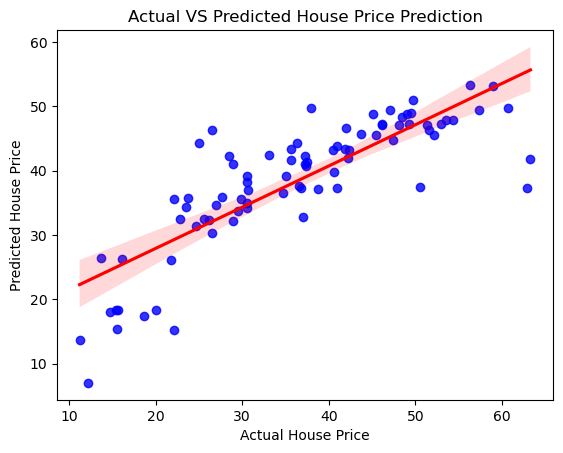

In [55]:
sns.regplot(x=Y_test, y=Y_pred, color='blue', line_kws={'color':'red'})
plt.xlabel('Actual House Price')
plt.ylabel('Predicted House Price')
plt.title('Actual VS Predicted House Price Prediction')
plt.show()

In [56]:
# linear regression sensitive to outlier
# from above figure outlier dherai xa so outlier nahataune vaye yo data ma linear regression use garna mildaina
# line and margin vanda jati najik teti ramro

In [57]:
'''
1. Cross Validation

2. Regularization
    i. Polynomial Regression
    -> To work with non linear feature pattern data
    -> x1, x2
    ->x1**2, x2**2
    ->x1x2
    
    ii. Ridge Regression (L2 Regression)
    -> If required to make weight near 0  to reduce biasness between features.
    -> alpha -> 1.0
    
    iii. Lasso Regression (L1 Regression)
    -> If required to remove feature execution from model making unwanted feature to 0.
    -> alpha -> 0.1
    
    iv. ElasticNet Regression
    -> Combination of L1 and L2.
    -> alpha = 0.1, l1_ratio = 0.5
    
3. Adjusting R2 Score
    -> 1-((1-r2)*(n-1))/(n-p-1)
    -> n -> number of test samples (X_test.shape)
    -> p -> number of features (X_train.shape)
    -> r2 -> Residual score
'''


'\n1. Cross Validation\n\n2. Regularization\n    i. Polynomial Regression\n    -> To work with non linear feature pattern data\n    -> x1, x2\n    ->x1**2, x2**2\n    ->x1x2\n    \n    ii. Ridge Regression (L2 Regression)\n    -> If required to make weight near 0  to reduce biasness between features.\n    -> alpha -> 1.0\n    \n    iii. Lasso Regression (L1 Regression)\n    -> If required to remove feature execution from model making unwanted feature to 0.\n    -> alpha -> 0.1\n    \n    iv. ElasticNet Regression\n    -> Combination of L1 and L2.\n    -> alpha = 0.1, l1_ratio = 0.5\n    \n3. Adjusting R2 Score\n    -> 1-((1-r2)*(n-1))/(n-p-1)\n    -> n -> number of test samples (X_test.shape)\n    -> p -> number of features (X_train.shape)\n    -> r2 -> Residual score\n'

# Cross validation

In [58]:
kfold = KFold(n_splits=5, shuffle=True, random_state=42) # train data->5 times
cv_score = cross_val_score(model, scaler.fit_transform(X), Y, scoring='r2')

print(f'Cross validation score: {cv_score}')
print(f'Average cross validation score: {cv_score.mean()}')

Cross validation score: [0.68463546 0.53209757 0.66649314 0.42112676 0.57912236]
Average cross validation score: 0.5766950593066446


# Adjusting R2 Score

In [59]:
def adjustR2(r2, n, p):
    return 1-((1-r2)*(n-1))/(n-p-1)

n_sample = X_test.shape[0]
p = X_train.shape[1]

## Model Implementation

In [60]:
model = LinearRegression()
# Train model
model.fit(X_train_scale, Y_train)


LinearRegression()

In [61]:
Y_pred = model.predict(X_test_scale)

# Polynomial Regression

In [62]:
poly = Pipeline([
    # Feature Scaling
    ('scaler',StandardScaler()),
    # Check for non linear feature pattern
    ('poly',PolynomialFeatures(degree = 2, include_bias = False)),
    # Check from the model
    ('linear',LinearRegression())
])
poly.fit(X_train, Y_train)
poly_predict = poly.predict(X_test)

poly_mae = mean_absolute_error(Y_test, poly_predict)
poly_mse = mean_squared_error(Y_test, poly_predict)
poly_rmse = np.sqrt(poly_mse)
poly_r2 = r2_score(Y_test, poly_predict)
poly_adjust_r2 = adjustR2(poly_r2, n_sample, p)
print(f'Mean Absolute Error(MAE):{poly_mae}')
print(f'Mean Squared Error(MSE):{poly_mse}')
print(f'Root Mean Squared Error(RMSE/Loss Function):{poly_rmse}')
print(f'R2 Score(Residual Score/ Cost Function):{poly_r2}')
print(f'Adjusted R2 Score: {poly_adjust_r2}')


Mean Absolute Error(MAE):4.812176820584432
Mean Squared Error(MSE):41.85048243854703
Root Mean Squared Error(RMSE/Loss Function):6.469194883333399
R2 Score(Residual Score/ Cost Function):0.7505332250103933
Adjusted R2 Score: 0.734334083777302


# Ridge Regression

In [63]:
ridge = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha = 1.0))
])
ridge.fit(X_train, Y_train)
ridge_pred = ridge.predict(X_test)

ridge_r2 = r2_score(Y_test, ridge_pred)
print(f'R2 Score(Residual Score/ Cost Function):{ridge_r2}')



R2 Score(Residual Score/ Cost Function):0.6749144123534498


# Lasso Regression

In [64]:
lasso = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Ridge(alpha = 0.1))
])
lasso.fit(X_train, Y_train)
lasso_pred = lasso.predict(X_test)

lasso_r2 = r2_score(Y_test, lasso_pred)
print(f'R2 Score(Residual Score/ Cost Function):{lasso_r2}')

R2 Score(Residual Score/ Cost Function):0.6746757475106016


# ElasticNet Regression

In [65]:
en = Pipeline([
    ('scaler', StandardScaler()),
    ('en', ElasticNet(alpha = 0.1, l1_ratio=0.5))
])
en.fit(X_train, Y_train)
en_pred = en.predict(X_test)

en_r2 = r2_score(Y_test, en_pred)
print(f'R2 Score(Residual Score/ Cost Function):{en_r2}')

R2 Score(Residual Score/ Cost Function):0.6766485702514125


# Random Forest Regressor

In [67]:
rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf_poly',PolynomialFeatures(degree=2, include_bias=False)),
    ('rf_regressor', RandomForestRegressor())
])
rf.fit(X_train, Y_train)
rf_pred = rf.predict(X_test)

rf_mae = mean_absolute_error(Y_test,rf_pred)
rf_mse = mean_squared_error(Y_test,rf_pred)
rf_rmse = np.sqrt(rf_mse)
r2 = r2_score(Y_test,rf_pred)

print(f'Mean Absolute Error(MAE):{rf_mae}')
print(f'Mean Squared Error(MSE):{rf_mse}')
print(f'Root Mean Squared Error(RMSE/Loss Function):{rf_rmse}')
print(f'R2 Score(Residual Score/ Cost Function):{r2}')

Mean Absolute Error(MAE):4.036731812966148
Mean Squared Error(MSE):32.04609463774481
Root Mean Squared Error(RMSE/Loss Function):5.660927012225542
R2 Score(Residual Score/ Cost Function):0.8089762551237276


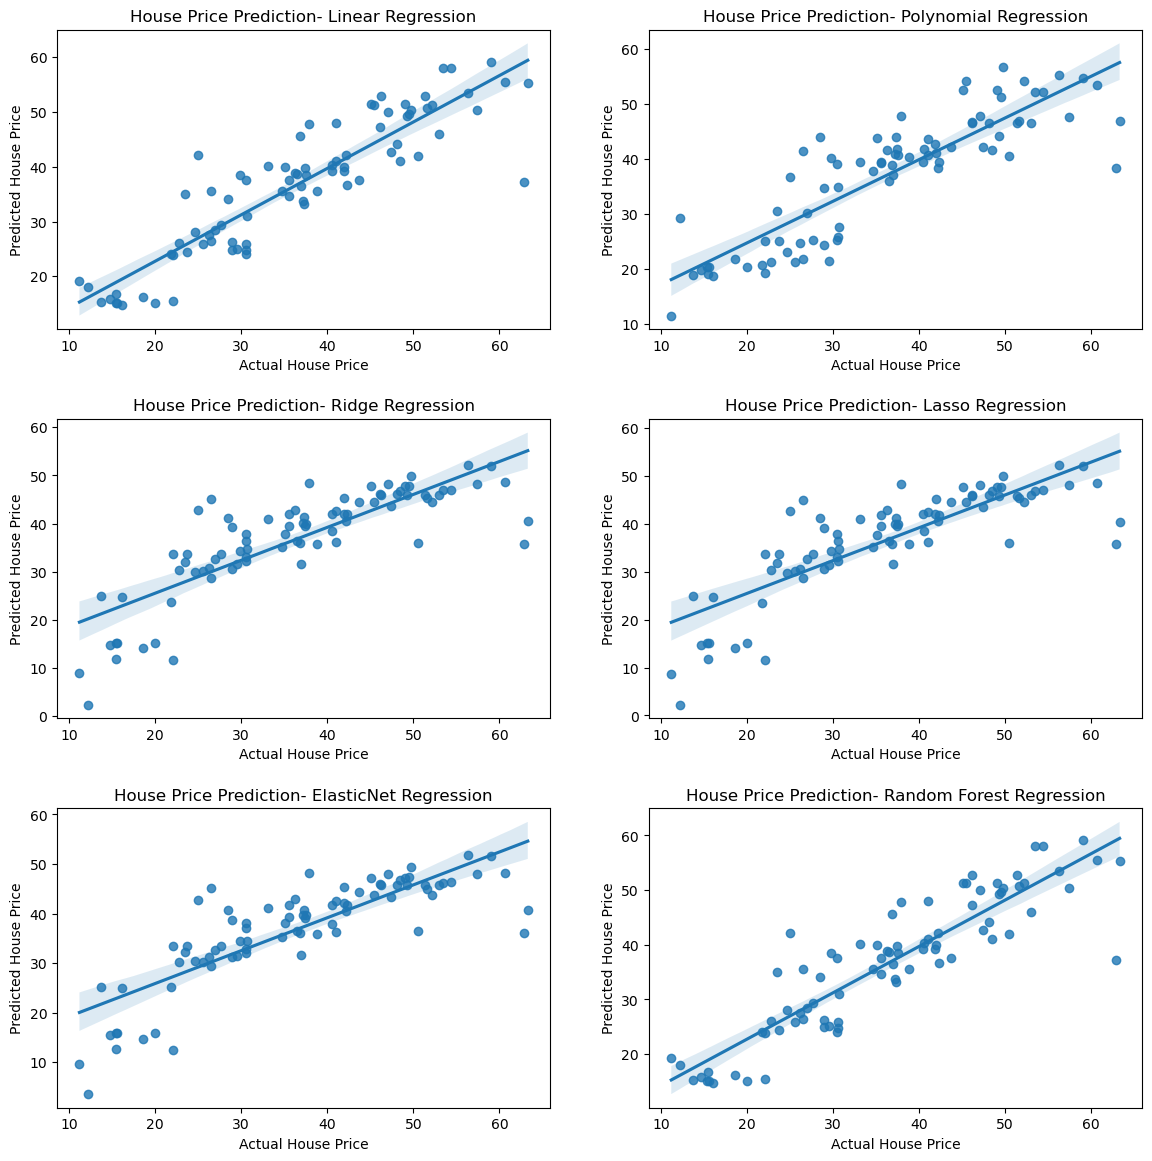

In [79]:
fig, axes = plt.subplots(3,2,figsize =(14,14))
plt.subplots_adjust(hspace=0.3)

sns.regplot(x=Y_test, y=rf_pred, ax=axes[0,0])
axes[0,0].set_title('House Price Prediction- Linear Regression')
axes[0,0].set_xlabel('Actual House Price')
axes[0,0].set_ylabel('Predicted House Price')

sns.regplot(x=Y_test, y=poly_predict, ax=axes[0,1])
axes[0,1].set_title(('House Price Prediction- Polynomial Regression'))
axes[0,1].set_xlabel('Actual House Price')
axes[0,1].set_ylabel('Predicted House Price')

sns.regplot(x=Y_test, y=ridge_pred, ax=axes[1,0])
axes[1,0].set_title(('House Price Prediction- Ridge Regression'))
axes[1,0].set_xlabel('Actual House Price')
axes[1,0].set_ylabel('Predicted House Price')

sns.regplot(x=Y_test, y=lasso_pred, ax=axes[1,1])
axes[1,1].set_title(('House Price Prediction- Lasso Regression'))
axes[1,1].set_xlabel('Actual House Price')
axes[1,1].set_ylabel('Predicted House Price')

sns.regplot(x=Y_test, y=en_pred, ax=axes[2,0])
axes[2,0].set_title(('House Price Prediction- ElasticNet Regression'))
axes[2,0].set_xlabel('Actual House Price')
axes[2,0].set_ylabel('Predicted House Price')

sns.regplot(x=Y_test, y=rf_pred, ax=axes[2,1])
axes[2,1].set_title(('House Price Prediction- Random Forest Regression'))
axes[2,1].set_xlabel('Actual House Price')
axes[2,1].set_ylabel('Predicted House Price')


plt.show()